In [1]:
import sys, os
import pickle as pk
import numpy as np
import pandas as pd
from itertools import product
import matplotlib.pyplot as plt
from rich import print as rprint
from multiprocessing import Pool

from utils import *

sys.path.append("../")
from sangrah.tools import get_info

sys.path.append('../../scripts_analysis')
from analysis import *

simTypes = {
    'control':     dict(d='control', r='result.dat', v='vesData.dat'),
    'without cross-talk': dict(d='control_eachCa', r='sresult_RRP_{}.dat', v='svesData_RRP_{}.dat'),
    'syt7KO':      dict(d='syt7KO', r='result.dat', v='vesData.dat'),
    'nonsatBuffer': dict(d='control_unsatBuffer', r='result.dat', v='vesData.dat')
}

dataPath = "../../data"

In [2]:
category_info_path = os.path.join(dataPath, 'control_eachCa/category_info.pk')
if os.path.exists(category_info_path):
    with open(category_info_path, "rb") as infile:
        category_info = pk.load(infile)

# rprint(category_info[0,0,0,0]['rep_design_median'])

categories = []
for category in category_info.ravel():
    # rprint(category)
    if category:
        categories.append(str(category['rep_design_median']))

# len(categories), categories

In [ ]:
def run_all(info, tstep=0.1):
    design, simType = info
    simInfo = get_info(design, skip=0)

    if simType == 'without cross-talk':
        design = design.split('RRP')[0] + 'ISI' + design.split('ISI')[1]
    resultDir = os.path.join(dataPath, simTypes[simType]['d'], design)
    RRP = simInfo['RRP']
    # print(design, RRP)

    # ves_data_file = 'vesData.dat' if simType == 'control' else 'svesData.dat'

    # print(simTypes[simType]['v'].format(RRP))
    inf = os.path.join(resultDir, simTypes[simType]['v'].format(RRP))
    with open(inf, "rb") as infile:
        vesData = pk.load(infile)
        # print(vesData.keys())
        
    if simType == 'control':
        vrel_times = [[(1+float(val))*1000 for val in vals] for vals in vesData[RRP]]
        # vrel_times = vrel_times[:50] ##### For testing
    else:
        seeds = len(vesData['AZ1']['sync'])
        vrel_times = [[] for _ in range(seeds)]
        for i in range(seeds):
            for az in list(vesData.keys()):
                for k in vesData[az].keys():
                    vrel_times[i] += vesData[az][k][i]*1000 # Convert to ms
    rprint(vrel_times)
    nMFB, spid, sptimes = get_spike_generator_info(vrel_times)
    # print(nMFB, np.array(spid), np.array(sptimes))

    # print(f"Running simulation for: {design}")
    stMCA3p, spMCA3p = run_sim(nMFB, spid, sptimes, tstep=tstep)
    # test_plot(stMCA3p, spMCA3p, vrel_times)

    ## Spike times of CA3p
    CA3p_spikes = [np.sort([t-1000 for t in (a/ms).tolist() if t>1000]) for a in 
                   spMCA3p.spike_trains().values()]
    
    ## Synaptic currents
    epscs = -stMCA3p.Isyn[:,int(1000/tstep):]/uA

    ## timepoints
    tt = stMCA3p.t[int(1000/tstep):]/ms - 1000

    ## Save the results
    out = os.path.join(resultDir, 'CA3p.pk')
    with open(out, "wb") as outfile:
        data = {
            'CA3p_spikes': CA3p_spikes, 
            'epse': epscs,
            'tpoints': tt
        }
        pk.dump(data, outfile)

    # return None
    return stMCA3p, spMCA3p, vrel_times
    # return vesData

design = categories[0]
stMCA3p, spMCA3p, rel = run_all([design, 'without cross-talk'])
# stMCA3p, spMCA3p, rel = run_all([design, 'control'])

(1000.0, 1210.0)

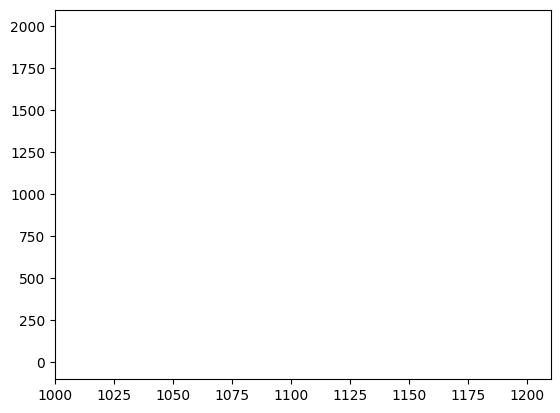

In [107]:
plt.plot(spMCA3p.t/ms, spMCA3p.i, '.')
plt.xlim(1000,1210)

In [ ]:
# for simType in simTypes:
#     for design in categories[:1]:
#         print(design, simType)
#         vesData = run_all([design, simType])

In [84]:
# info = list(product(categories, simTypes.keys()))
# with Pool(20) as p:
#     p.map(run_all, info)

In [86]:
simType = 'without cross-talk'
if simType == 'without cross-talk':
    design = design.split('RRP')[0] + 'ISI' + design.split('ISI')[1]

ca3p = os.path.join(dataPath, simTypes[simType]['d'], design, 'CA3p.pk')
with open(ca3p, "rb") as infile:
    ca3 = pk.load(infile)

print(ca3.keys())

dict_keys(['CA3p_spikes', 'epse', 'tpoints'])


In [ ]:
apProb, ap1Prob = getAPprob(ca3p)
apProb, ap1Prob

(array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]))

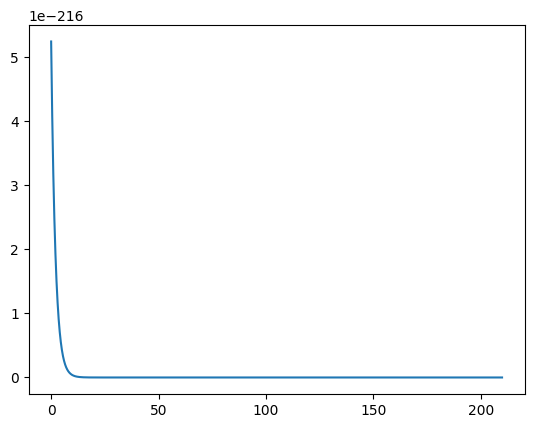

In [ ]:
plt.plot(ca3['tpoints'], np.mean(ca3['epse'], axis=0))